# 11 — Skill-Requirement Models: Evaluation & Summary Table

This notebook evaluates all 27 binary **skill-requirement models** trained in Chapter 1 and compiles their performance into a unified results table.  
Each model predicts whether a given skill group (e.g., *core_programming__basic*) is required for a job based on company attributes, role attributes, and all other skill indicators.

---

## **Goals of This Notebook**
- Load the processed dataset used for training skill models.
- For each of the 27 skill groups:
  - Recreate the train/test split.
  - Load the corresponding LightGBM model from disk.
  - Run the full evaluation pipeline (ROC AUC, PR AUC, Brier score, prevalence).
  - Extract the model's hyperparameters.
  - Extract full feature importances.
- Build a **single consolidated dataframe** where:
  - Each row corresponds to one skill model.
  - Columns contain performance metrics, model parameters, and feature-importance values aligned to their feature names.

---

## **What This Notebook Produces**
1. **A complete evaluation table** containing:
   - Train/test ROC AUC  
   - Train/test PR AUC  
   - Test Brier score  
   - Prevalence of the skill  
   - Hyperparameters used (learning rate, num leaves, n estimators, etc.)  
   - Variable-importance scores for every non-target feature  

2. **A reproducible evaluation pipeline** using the helper function  
   `evaluate_skill_model()`  
   which:
   - Loads the correct model from disk  
   - Applies consistent feature selection  
   - Computes metrics  
   - Returns both metrics and a tidy importance table  

3. **A modelling-ready summary dataframe** for downstream analysis:
   - Skill difficulty  
   - Predictability  
   - Feature drivers of each skill  
   - Prevalence–performance relationships  

---

## **Outcome**
This notebook provides the **complete diagnostic view** of all 27 skill models.  
It forms the analytical backbone for interpreting model behaviour, comparing skill predictability, and integrating the results into later chapters (probability matrix construction, recommender logic, and skill-value insights).

All output from this notebook remains internal to Chapter 1 and supports the next step: generating the **skill probability matrix** for all jobs.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys
from pathlib import Path
import pkgutil
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root


from src.job_intel.config import CH1_PROCESSED_SALARY_MODEL_PCA_DF

from src.job_intel.evaluation.skill_model_eval import evaluate_skill_model


In [2]:
from sklearn.model_selection import train_test_split


df = pd.read_csv(CH1_PROCESSED_SALARY_MODEL_PCA_DF)


skills = ['core_programming__basic', 'core_programming__intermediate', 
            'core_programming__advanced', 'data_engineering_pipelines__basic',
            'data_engineering_pipelines__intermediate',
            'data_engineering_pipelines__advanced', 'ml_ai__basic',
            'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
            'analytics_stats__intermediate', 'analytics_stats__advanced',
            'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
            'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
            'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
            'productivity_workflow__basic', 'productivity_workflow__intermediate',
            'productivity_workflow__advanced', 'soft_skills__core',
            'soft_skills__leadership', 'domain_specific__none']

all_features = df[[
            # Company
            'size_code', 'sector_code', 'state_code','ownership_code',
            # Role
            'seniority_code', 'title_rich_code',
            # Skills
            'core_programming__basic', 'core_programming__intermediate', 
            'core_programming__advanced', 'data_engineering_pipelines__basic',
            'data_engineering_pipelines__intermediate',
            'data_engineering_pipelines__advanced', 'ml_ai__basic',
            'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
            'analytics_stats__intermediate', 'analytics_stats__advanced',
            'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
            'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
            'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
            'productivity_workflow__basic', 'productivity_workflow__intermediate',
            'productivity_workflow__advanced', 'soft_skills__core',
            'soft_skills__leadership', 'domain_specific__none',
            ]].copy()

cat_cols = [
    'size_code', 'sector_code', 'state_code', 'ownership_code', 'seniority_code', 'title_rich_code'
]
all_features[cat_cols] = all_features[cat_cols].astype('category')

cols = ['model',
        'pos_frac_train',
        'pos_frac_test',
        'roc_auc_train',
        'roc_auc_test',
        'pr_auc_train',
        'pr_auc_test',
        'brier_test',
        'learning_rate',
        'n_estimators',
        'num_leaves',
        'colsample_bytree',
        'subsample',
        'size_code', 'sector_code', 'state_code','ownership_code',
        'seniority_code', 'title_rich_code',
        'core_programming__basic', 'core_programming__intermediate', 
        'core_programming__advanced', 'data_engineering_pipelines__basic',
        'data_engineering_pipelines__intermediate',
        'data_engineering_pipelines__advanced', 'ml_ai__basic',
        'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
        'analytics_stats__intermediate', 'analytics_stats__advanced',
        'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
        'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
        'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
        'productivity_workflow__basic', 'productivity_workflow__intermediate',
        'productivity_workflow__advanced', 'soft_skills__core',
        'soft_skills__leadership', 'domain_specific__none',]

In [4]:
results_df = pd.DataFrame()

for target in skills:

    y = df[target]
    X = all_features.drop(target, axis = 1)


    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )
    metrics, var_imp = evaluate_skill_model(
        response_name = target,
        X_train = X_train,
        y_train = y_train,
        X_test = X_test,
        y_test = y_test,
        model= None,
        show_plots = False)
    
    def build_eval_row(metrics: dict, var_imp: pd.DataFrame, all_cols: list[str]) -> pd.DataFrame:
        # Start with NaN for everything
        row = {col: np.nan for col in all_cols}

        # Model id
        
        row['model'] = target

        # fill metrics
        for k, v in metrics.items():
            if k in row:
                row[k] = v

        # fill variable importance
        # var_imp has columns: ["feature", "importance"]
        for _, r in var_imp.iterrows():
            feat = r["feature"]
            imp = r["importance"]
            if feat in row:
                row[feat] = imp
        

        # return as single-row DataFrame
        return pd.DataFrame([row])
    
    row_df = build_eval_row(metrics, var_imp, cols)
    results_df = pd.concat([results_df, row_df], ignore_index=True)



In [5]:
results_df

,model,pos_frac_train,pos_frac_test,roc_auc_train,roc_auc_test,pr_auc_train,pr_auc_test,brier_test,learning_rate,n_estimators,...,cloud__advanced,db_storage__basic,db_storage__intermediate,db_storage__advanced,productivity_workflow__basic,productivity_workflow__intermediate,productivity_workflow__advanced,soft_skills__core,soft_skills__leadership,domain_specific__none
0,core_programming__basic,0.586242,0.586375,0.999998,0.910095,0.999998,0.933017,0.118962,0.025,800,...,150.0,6806.0,5860.0,153.0,2141.0,3271.0,0.0,4992.0,9574.0,8704.0
1,core_programming__intermediate,0.096997,0.097324,1.000000,0.910692,1.000000,0.665227,0.058005,0.015,800,...,734.0,6355.0,6387.0,1121.0,2740.0,4994.0,0.0,4328.0,7040.0,5970.0
2,core_programming__advanced,0.002029,0.002433,1.000000,0.944986,1.000000,0.671521,0.001027,0.050,400,...,141.0,2259.0,1615.0,533.0,1190.0,1402.0,0.0,1245.0,2526.0,2598.0
3,data_engineering_pipelines__basic,0.018060,0.017843,1.000000,0.799452,1.000000,0.360724,0.016073,0.015,400,...,489.0,3372.0,4138.0,558.0,1193.0,2861.0,0.0,1823.0,2798.0,2549.0
4,data_engineering_pipelines__intermediate,0.385958,0.386050,0.999999,0.920441,0.999998,0.885236,0.115040,0.025,1000,...,282.0,8950.0,6003.0,332.0,3226.0,4830.0,0.0,5960.0,9177.0,9190.0
5,data_engineering_pipelines__advanced,0.191761,0.192214,0.999813,0.889050,0.999091,0.764033,0.089193,0.025,400,...,171.0,3367.0,2933.0,206.0,1701.0,2374.0,0.0,1703.0,3293.0,3353.0
6,ml_ai__basic,0.207589,0.207624,0.999992,0.902568,0.999965,0.795739,0.089483,0.015,1000,...,279.0,8950.0,5733.0,368.0,3069.0,4344.0,0.0,4607.0,9820.0,9686.0
7,ml_ai__intermediate,0.200081,0.200324,0.999999,0.922711,0.999997,0.823396,0.073188,0.015,1000,...,242.0,9168.0,5345.0,297.0,3540.0,4357.0,0.0,4073.0,9824.0,9850.0
8,ml_ai__advanced,0.079951,0.079481,0.999999,0.941688,0.999987,0.771496,0.036469,0.025,400,...,510.0,3616.0,2191.0,160.0,1699.0,2044.0,0.0,2133.0,3926.0,3910.0
9,analytics_stats__basic,0.680195,0.680454,0.999908,0.869787,0.999960,0.924374,0.130827,0.025,1000,...,173.0,10042.0,6755.0,421.0,3053.0,4227.0,0.0,5864.0,11765.0,9774.0


### Save output

In [ ]:
from src.job_intel.config import PROCESSED_DATA_DIR
results_df.to_csv(PROCESSED_DATA_DIR / 'skill_model_evaluation_result.csv', index=False)

## Metrics visualisation and high-level interpretation

In [6]:
results_df.describe()

,pos_frac_train,pos_frac_test,roc_auc_train,roc_auc_test,pr_auc_train,pr_auc_test,brier_test,learning_rate,n_estimators,num_leaves,...,cloud__advanced,db_storage__basic,db_storage__intermediate,db_storage__advanced,productivity_workflow__basic,productivity_workflow__intermediate,productivity_workflow__advanced,soft_skills__core,soft_skills__leadership,domain_specific__none
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.0,...,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.0,26.000000,26.000000,26.000000
mean,0.242898,0.242949,0.999980,0.896983,0.999946,0.753580,0.076475,0.027593,733.333333,127.0,...,311.153846,6150.500000,4872.038462,422.538462,2417.346154,3590.384615,0.0,3607.192308,6740.807692,6464.500000
std,0.232559,0.232648,0.000046,0.046962,0.000177,0.162611,0.050705,0.012962,271.746488,0.0,...,265.553865,2770.553667,1794.451749,277.652478,896.944544,1430.242359,0.0,1629.541286,3241.728539,2917.849719
min,0.002029,0.002433,0.999813,0.799452,0.999091,0.360724,0.000311,0.015000,400.000000,127.0,...,12.000000,2259.000000,1615.000000,17.000000,933.000000,1402.000000,0.0,1245.000000,2526.000000,2244.000000
25%,0.053571,0.053122,0.999990,0.870335,0.999971,0.687745,0.026271,0.015000,400.000000,127.0,...,152.000000,3376.000000,3368.250000,224.750000,1495.000000,2257.000000,0.0,1922.250000,3496.500000,3684.250000
50%,0.191761,0.192214,0.999999,0.905397,0.999997,0.771496,0.082050,0.025000,800.000000,127.0,...,246.500000,6404.000000,5655.500000,357.500000,2636.500000,3704.500000,0.0,3933.500000,6900.000000,7060.000000
75%,0.355925,0.356042,1.000000,0.922515,1.000000,0.867222,0.112869,0.025000,1000.000000,127.0,...,397.500000,8950.000000,6380.000000,528.250000,3094.500000,4368.500000,0.0,4896.750000,9504.250000,9068.500000
max,0.787946,0.788321,1.000000,1.000000,1.000000,1.000000,0.168881,0.050000,1000.000000,127.0,...,1048.000000,10042.000000,7041.000000,1162.000000,3932.000000,6357.000000,0.0,6149.000000,11765.000000,12137.000000


In [ ]:
results_df[['model','pos_frac_train', 'pr_auc_test']].sort_values(by='pr_auc_test')

### Brier Score — Probability Calibration Quality

The Brier scores fall mostly between 0.05 and 0.12, with a small cluster of extremely low values near 0.00 for skills with very high prevalence. A lower Brier score indicates better calibration: predicted probabilities are close to the true empirical frequencies. Scores under ~0.12 reflect well-calibrated, sharply defined probabilities, meaning the model’s predicted skill probabilities can be interpreted directly and used safely in downstream applications such as job–job similarity and user–job matching. Even for rarer skills, the calibration penalty remains modest, confirming that the models produce stable, meaningful probability estimates.

### Interpretation

* 0.0 = perfect probabilistic predictions
* 0.25 = equivalent to always predicting 0.5
* over 0.25 = bad (worse than guessing)
* 1.0 = worst possible


Text(0.5, 1.0, 'Brier test')

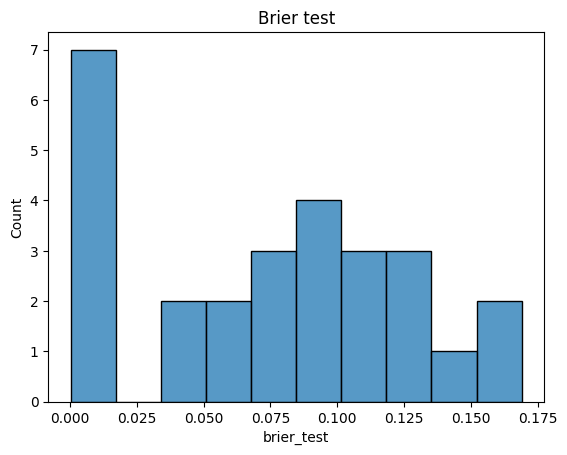

In [7]:
sns.histplot(
    data = results_df,
    x = 'brier_test',
    bins = 10
)

plt.title("Brier test")


### ROC AUC — Discrimination Ability

The ROC AUC distribution shows that almost all models achieve excellent discrimination, with most values clustered between 0.88 and 0.95, and only a few dipping toward 0.80. This means the models separate positive vs. negative skill occurrences very effectively across nearly all skill groups. A high ROC AUC confirms that LightGBM is reliably ranking jobs that truly require a skill higher than jobs that do not, independent of the skill’s prevalence. This is exactly what we want for a probability-based skill model.

### Interpretation

* 0.80–0.85 → good
* 0.85–0.90 → very good
* 0.90–0.95 → excellent
* 0.95+ → near-perfect discrimination

In [ ]:
sns.histplot(
    data = results_df,
    x = 'roc_auc_test',
    bins = 10
)

plt.title("ROC AUC")

### PR AUC — Performance Under Class Imbalance

The PR AUC values range widely, from ~0.40 for rare skills to ~0.95 for common or highly structured skills. This behaviour is expected: PR AUC is directly influenced by the base prevalence of each skill. Skills that occur frequently and have strong structural patterns in the job attributes achieve very high PR AUC, while sparse or weakly structured skills naturally show lower values. Importantly, even the lower PR AUC models still perform meaningfully above their prevalence baselines, demonstrating that the models are learning real signal rather than noise.



| PR AUC      | Interpretation                          |
| ----------- | --------------------------------------- |
| 0.30–0.50 | Rare or noisy skill; still acceptable   |
| 0.50–0.70 | Moderate performance; decent signal     |
| 0.70–0.85 | Strong model; good separation           |
| 0.85–0.95 | Very strong                             |
| 0.95+     | Almost perfect precision at high recall |

In [ ]:
sns.histplot(
    data = results_df,
    x = 'pr_auc_test',
    bins = 10
)

plt.title("PR AUC")

## Model parameters viz

In [ ]:
sns.histplot(
    data = results_df,
    x = 'learning_rate',
    bins = 10
)

plt.title("Learning rate")

In [ ]:
sns.histplot(
    data = results_df,
    x = 'n_estimators',
    bins = 10
)

plt.title("Estimators")

In [ ]:
var_importance = results_df.iloc[:,13:].fillna(0).corr()
var_importance